Train a simple network on a set of datapoints that are in two classes. around the unit circle. 

In [29]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 10000
x_min, x_max, y_min, y_max = -10, 10, -10, 10
X = np.random.uniform(x_min, x_max, size=(n, 2))

# distance from origin
r = np.sqrt(X[:, 0]**2 + X[:, 1]**2)
r = np.sin(X[:, :1]) - np.cos(X[:, 1:])
print(r.mean())
y = (r < 0.05).astype(int)
print(y.mean())
print(y.shape)


0.04958438096754692
0.5098
(10000, 1)


/var/folders/4j/b7q3_s_d15v7rtfmjk70r1wh0000gn/T/ipykernel_8284/2544910058.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


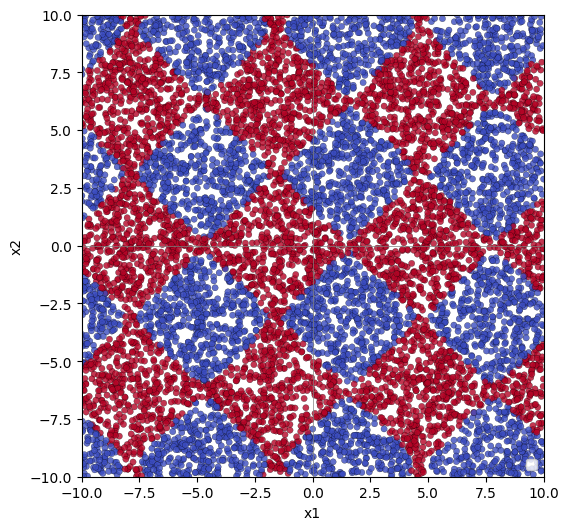

In [30]:

# plot

def plot_grid(x, y, x_min=-10, x_max=10, y_min = -10, y_max=10):
    
    plt.figure(figsize=(6, 6))
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap='coolwarm', s=20, alpha=0.8, edgecolors='k', linewidths=0.2)
    plt.axhline(0, color='gray', lw=0.5)
    plt.axvline(0, color='gray', lw=0.5)

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.show()

plot_grid(X, y)

In [31]:
import torch
import torch.nn as nn
class Model(nn.Module):

    def __init__(self, input_dim: int, hidden_dim: int, num_layers: int, num_classes: int):
        super().__init__()

        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.ReLU()]
        layers.append(nn.Linear(hidden_dim, num_classes))

        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

model = Model(input_dim=2, hidden_dim=64, num_layers=2, num_classes=2)
dummy = torch.randn(8, 2)
print(model)
print("output shape:", model(dummy).shape)

Model(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)
output shape: torch.Size([8, 2])


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np

batch_size = 512

X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.long).squeeze(1)
print(y_t.shape)

train_loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

# --- output handles so each display area updates in place ---
from IPython.display import HTML
batch_out = display(display_id=True)
epoch_out = display(display_id=True)

def render_frame(xb, yb, logits, epoch, batch_idx, loss):
    """Updates the batch-level display in place each step."""
    with torch.no_grad():
        probs = torch.softmax(logits, dim=1)
        conf = (probs[:, 1] - probs[:, 0]).cpu().numpy()

    x_np = xb.cpu().numpy()
    y_np = yb.cpu().numpy()

    cmap = plt.cm.coolwarm
    norm = plt.Normalize(vmin=-1, vmax=1)
    rgba = cmap(norm(conf))
    rgba[:, 3] = np.abs(conf) ** 0.6
    lw = np.abs(conf) * 0.8

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Epoch {epoch+1}  |  Batch {batch_idx}  |  Loss {loss:.4f}", fontsize=13)

    # left: true labels
    axes[0].scatter(x_np[:, 0], x_np[:, 1], c=y_np, cmap='coolwarm',
                    s=16, alpha=0.8, edgecolors='k', linewidths=0.2)
    axes[0].set_title('True labels (batch)')

    # middle: certainty axis
    axes[1].scatter(conf, x_np[:, 1], c=y_np, cmap='coolwarm',
                    s=16, alpha=0.8, edgecolors='k', linewidths=0.2)
    axes[1].axvline(0, color='black', lw=0.8)
    axes[1].axvline(-1, color='gray', lw=0.7, ls='--')
    axes[1].axvline( 1, color='gray', lw=0.7, ls='--')
    axes[1].set_title('Certainty axis (batch)')

    # right: confidence overlay
    axes[2].set_facecolor('#cccccc')
    axes[2].scatter(x_np[:, 0], x_np[:, 1], color=rgba, s=16,
                    edgecolors=rgba * [0.4, 0.4, 0.4, 1], linewidths=lw)
    axes[2].set_title('Confidence overlay (batch)')

    for i, ax in enumerate(axes):
        ax.axhline(0, color='gray', lw=0.5)
        ax.axvline(0, color='gray', lw=0.5)
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        if i != 1:
            ax.set_aspect('equal', 'box')

    axes[1].set_xlabel('certainty  (← class 0  |  class 1 →)')
    axes[1].set_xlim(-1.05, 1.05)

    batch_out.update(fig)
    plt.close(fig)


def eval_epoch(model, X_t, y_t, epoch, avg_loss):
    """Runs model on the full dataset and renders a standalone epoch summary."""
    model.eval()
    with torch.no_grad():
        logits = model(X_t)
        probs  = torch.softmax(logits, dim=1)
        conf   = (probs[:, 1] - probs[:, 0]).cpu().numpy()

    x_np = X_t.cpu().numpy()
    y_np = y_t.cpu().numpy()

    cmap = plt.cm.coolwarm
    norm = plt.Normalize(vmin=-1, vmax=1)
    rgba = cmap(norm(conf))
    rgba[:, 3] = np.abs(conf) ** 0.6
    lw = np.abs(conf) * 0.8

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Epoch {epoch+1} — full dataset eval  |  Avg loss {avg_loss:.4f}", fontsize=13)

    # left: true labels (all points)
    axes[0].scatter(x_np[:, 0], x_np[:, 1], c=y_np, cmap='coolwarm',
                    s=6, alpha=0.5, edgecolors='none')
    axes[0].set_title('True labels (all data)')

    # middle: certainty axis (all points)
    axes[1].scatter(conf, x_np[:, 1], c=y_np, cmap='coolwarm',
                    s=6, alpha=0.5, edgecolors='none')
    axes[1].axvline(0, color='black', lw=0.8)
    axes[1].axvline(-1, color='gray', lw=0.7, ls='--')
    axes[1].axvline( 1, color='gray', lw=0.7, ls='--')
    axes[1].set_title('Certainty axis (all data)')

    # right: full confidence overlay
    axes[2].set_facecolor('#cccccc')
    axes[2].scatter(x_np[:, 0], x_np[:, 1], color=rgba, s=6,
                    edgecolors=rgba * [0.4, 0.4, 0.4, 1], linewidths=lw * 0.5)
    axes[2].set_title('Confidence overlay (all data)')

    for i, ax in enumerate(axes):
        ax.axhline(0, color='gray', lw=0.5)
        ax.axvline(0, color='gray', lw=0.5)
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        if i != 1:
            ax.set_aspect('equal', 'box')

    axes[1].set_xlabel('certainty  (← class 0  |  class 1 →)')
    axes[1].set_xlim(-1.05, 1.05)

    epoch_out.update(fig)
    plt.close(fig)


for epoch in range(100):
    model.train()
    total_loss = 0.0
    for batch_idx, (xb, yb) in enumerate(train_loader):
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        render_frame(xb, yb, logits, epoch, batch_idx, loss.item())

    avg_loss = total_loss / len(train_loader.dataset)
    eval_epoch(model, X_t, y_t, epoch, avg_loss)
    print(f"Epoch {epoch + 1}: loss={avg_loss:.4f}")